# Task 2: Price Range Analysis

## Objective

Analyze restaurant price ranges and their relationship with ratings.

This notebook answers three questions from the Cognifyz Level 2 brief:

1. What is the most common price range?
2. What is the average rating for each price range?
3. Which rating color represents the highest average rating among price ranges?

The original `Dataset.csv` is read only. It is not modified.

Rating colors are taken from the dataset. They are not assigned from a plotting palette.


## Dataset Overview

Relevant columns used in this task:

- `Price range`
- `Aggregate rating`
- `Rating color`
- `Rating text`


## Import Libraries


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

BASE_DIR = Path.cwd()
DATA_PATH = (BASE_DIR / "../Dataset.csv").resolve()
FIG_DIR = BASE_DIR / "outputs" / "figures"
TAB_DIR = BASE_DIR / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", BASE_DIR)
print("Dataset path:", DATA_PATH)


Working directory: C:\Users\adity\Documents\Cognifyz\Level-2\Task-2_Price_Range_Analysis
Dataset path: C:\Users\adity\Documents\Cognifyz\Level-2\Dataset.csv


## Load Dataset


In [2]:
df = pd.read_csv(DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()


Rows: 9551
Columns: 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Data Validation


In [3]:
print("Missing values in analysis columns:")
print(df[["Price range", "Aggregate rating", "Rating color", "Rating text"]].isna().sum())
print()
print("Price range unique values:", sorted(df["Price range"].unique().tolist()))
print()
print("Rating color unique values:", df["Rating color"].unique().tolist())
print()
print("Rating text unique values:", df["Rating text"].unique().tolist())
print()
print("Rating color vs Rating text:")
print(pd.crosstab(df["Rating color"], df["Rating text"]))
print()
print("Aggregate rating by Rating color:")
print(
    df.groupby("Rating color")["Aggregate rating"]
    .agg(["min", "max", "mean", "count"])
    .sort_values("mean")
)


Missing values in analysis columns:
Price range         0
Aggregate rating    0
Rating color        0
Rating text         0
dtype: int64

Price range unique values: [1, 2, 3, 4]

Rating color unique values: ['Dark Green', 'Green', 'Yellow', 'Orange', 'White', 'Red']

Rating text unique values: ['Excellent', 'Very Good', 'Good', 'Average', 'Not rated', 'Poor']

Rating color vs Rating text:
Rating text   Average  Excellent  Good  Not rated  Poor  Very Good
Rating color                                                      
Dark Green          0        301     0          0     0          0
Green               0          0     0          0     0       1079
Orange           3737          0     0          0     0          0
Red                 0          0     0          0   186          0
White               0          0     0       2148     0          0
Yellow              0          0  2100          0     0          0

Aggregate rating by Rating color:
              min  max      mean  cou

## Analysis: Price Range Distribution

The most common price range is the value with the highest restaurant count.


In [4]:
total_restaurants = len(df)

price_counts = df["Price range"].value_counts().sort_index()
price_distribution = pd.DataFrame({
    "Price Range": price_counts.index,
    "Restaurant Count": price_counts.values,
})
price_distribution["Percentage"] = (
    price_distribution["Restaurant Count"] / total_restaurants * 100
).round(2)

most_common_row = price_distribution.loc[price_distribution["Restaurant Count"].idxmax()]
most_common_price_range = int(most_common_row["Price Range"])

price_distribution.to_csv(TAB_DIR / "price_range_distribution.csv", index=False)
print("Most common price range:", most_common_price_range)
price_distribution


Most common price range: 1


,Price Range,Restaurant Count,Percentage
0,1,4444,46.53
1,2,3113,32.59
2,3,1408,14.74
3,4,586,6.14


## Visualization: Price Range Distribution


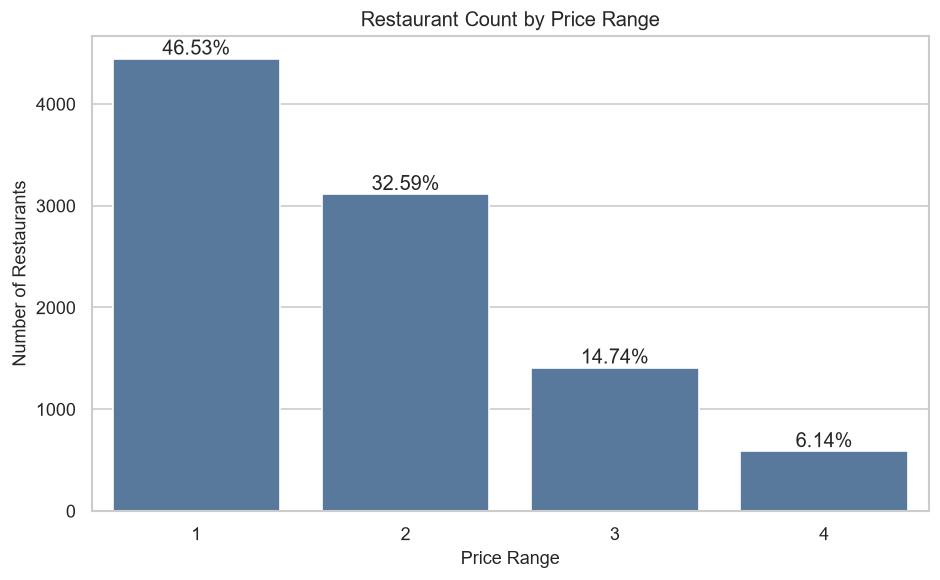

In [5]:
fig, ax = plt.subplots()
sns.barplot(
    data=price_distribution,
    x="Price Range",
    y="Restaurant Count",
    color="#4C78A8",
    ax=ax,
)
ax.set_title("Restaurant Count by Price Range")
ax.set_xlabel("Price Range")
ax.set_ylabel("Number of Restaurants")
for i, row in price_distribution.iterrows():
    ax.text(
        i,
        row["Restaurant Count"],
        f'{row["Percentage"]:.2f}%',
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "price_range_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## Analysis: Average Rating by Price Range


In [6]:
rating_by_price = (
    df.groupby("Price range", as_index=False)
    .agg(
        Number_of_Restaurants=("Aggregate rating", "count"),
        Average_Rating=("Aggregate rating", "mean"),
    )
    .rename(columns={"Price range": "Price Range"})
)
rating_by_price["Average_Rating"] = rating_by_price["Average_Rating"].round(3)

highest_rating_row = rating_by_price.loc[rating_by_price["Average_Rating"].idxmax()]
lowest_rating_row = rating_by_price.loc[rating_by_price["Average_Rating"].idxmin()]

rating_by_price.to_csv(TAB_DIR / "average_rating_by_price_range.csv", index=False)
print(
    "Highest average rating: price range",
    int(highest_rating_row["Price Range"]),
    "=",
    float(highest_rating_row["Average_Rating"]),
)
print(
    "Lowest average rating: price range",
    int(lowest_rating_row["Price Range"]),
    "=",
    float(lowest_rating_row["Average_Rating"]),
)
rating_by_price


Highest average rating: price range 4 = 3.818
Lowest average rating: price range 1 = 2.0


,Price Range,Number_of_Restaurants,Average_Rating
0,1,4444,2.000
1,2,3113,2.941
2,3,1408,3.683
3,4,586,3.818


## Visualization: Average Rating by Price Range


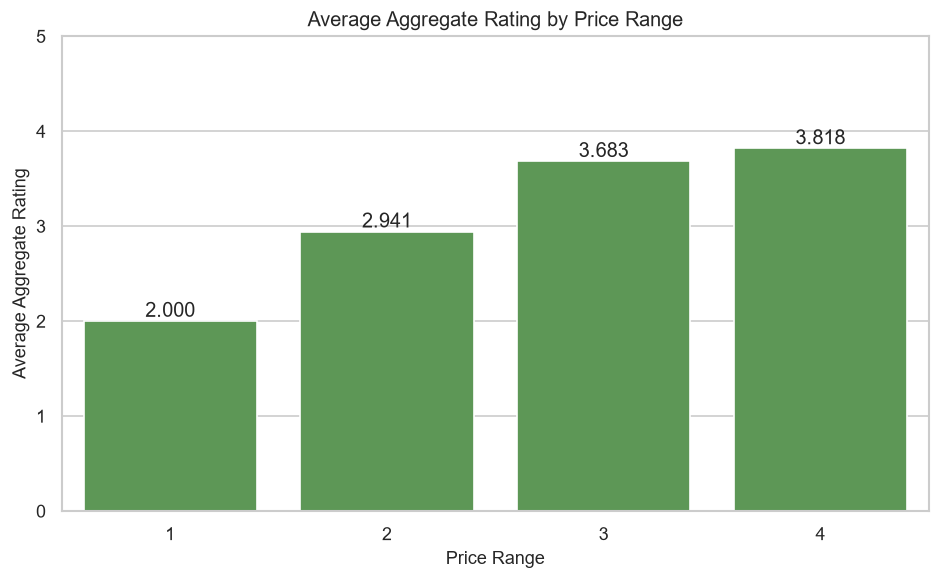

In [7]:
fig, ax = plt.subplots()
sns.barplot(
    data=rating_by_price,
    x="Price Range",
    y="Average_Rating",
    color="#54A24B",
    ax=ax,
)
ax.set_title("Average Aggregate Rating by Price Range")
ax.set_xlabel("Price Range")
ax.set_ylabel("Average Aggregate Rating")
ax.set_ylim(0, 5)
for i, row in rating_by_price.iterrows():
    ax.text(
        i,
        row["Average_Rating"],
        f'{row["Average_Rating"]:.3f}',
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "average_rating_by_price_range.png", dpi=300, bbox_inches="tight")
plt.show()


## Analysis: Rating Color for the Highest Average Rating

`Rating color` in this dataset is a discrete label tied to `Aggregate rating` bands. The mapping is derived from the data, not from a chart palette.

Method:

1. Compute the average `Aggregate rating` for each price range.
2. Identify the price range with the highest average rating.
3. Map that average rating onto the dataset's rating-color bands.
4. Also report the most frequent `Rating color` inside that price range, as a check.


In [8]:
color_stats = (
    df.groupby(["Rating color", "Rating text"], as_index=False)["Aggregate rating"]
    .agg(min_rating="min", max_rating="max", mean_rating="mean", count="count")
    .sort_values("min_rating")
)
color_stats.to_csv(TAB_DIR / "rating_color_bands.csv", index=False)
color_stats


,Rating color,Rating text,min_rating,max_rating,mean_rating,count
4,White,Not rated,0.0,0.0,0.000000,2148
3,Red,Poor,1.8,2.4,2.297849,186
2,Orange,Average,2.5,3.4,3.051619,3737
5,Yellow,Good,3.5,3.9,3.683429,2100
1,Green,Very Good,4.0,4.4,4.168119,1079
0,Dark Green,Excellent,4.5,4.9,4.659801,301


In [9]:
def rating_color_for_value(rating, stats=color_stats):
    # Map a numeric rating onto the dataset's observed color bands.
    for _, row in stats.iterrows():
        if row["min_rating"] <= rating <= row["max_rating"]:
            return row["Rating color"], row["Rating text"]
    # If a mean falls in a gap between bands, choose the nearest band.
    distances = []
    for _, row in stats.iterrows():
        if rating < row["min_rating"]:
            dist = row["min_rating"] - rating
        else:
            dist = rating - row["max_rating"]
        distances.append((dist, row["Rating color"], row["Rating text"]))
    distances.sort()
    return distances[0][1], distances[0][2]


highest_avg = float(highest_rating_row["Average_Rating"])
highest_price = int(highest_rating_row["Price Range"])
mapped_color, mapped_text = rating_color_for_value(highest_avg)

subset = df[df["Price range"] == highest_price]
mode_color = subset["Rating color"].mode().iloc[0]
mode_text = subset.loc[subset["Rating color"] == mode_color, "Rating text"].mode().iloc[0]

color_result = pd.DataFrame({
    "Item": [
        "Price range with highest average rating",
        "Highest average aggregate rating",
        "Dataset rating color for that average",
        "Dataset rating text for that average",
        "Most frequent rating color in that price range",
        "Most frequent rating text in that price range",
    ],
    "Value": [
        highest_price,
        round(highest_avg, 3),
        mapped_color,
        mapped_text,
        mode_color,
        mode_text,
    ],
})
color_result.to_csv(TAB_DIR / "rating_color_for_highest_average.csv", index=False)
color_result


,Item,Value
0,Price range with highest average rating,4
1,Highest average aggregate rating,3.818
2,Dataset rating color for that average,Yellow
3,Dataset rating text for that average,Good
4,Most frequent rating color in that price range,Yellow
5,Most frequent rating text in that price range,Good


## Visualization: Rating Color Bands


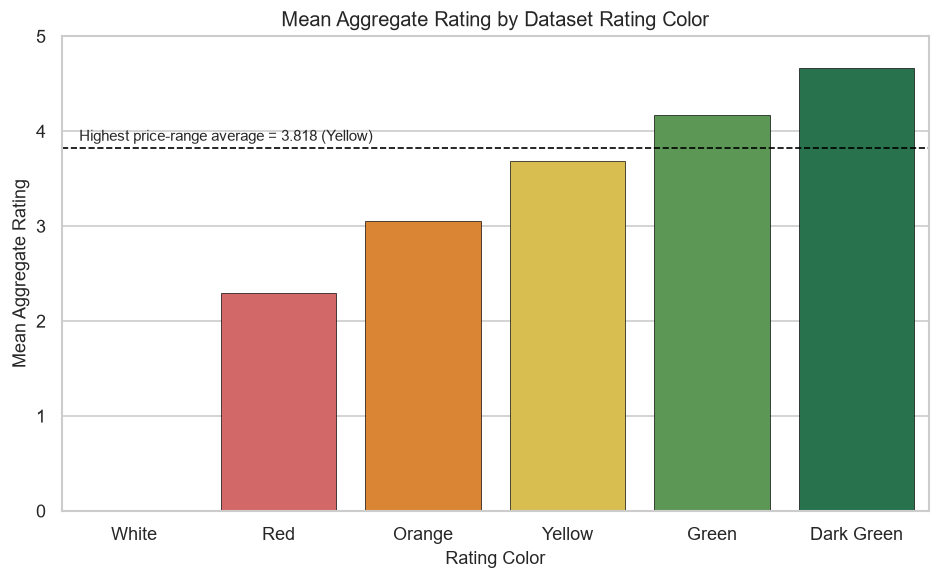

In [10]:
dataset_palette = {
    "White": "#F2F2F2",
    "Red": "#E45756",
    "Orange": "#F58518",
    "Yellow": "#EECA3B",
    "Green": "#54A24B",
    "Dark Green": "#1B7F4E",
}
order = color_stats["Rating color"].tolist()

fig, ax = plt.subplots()
sns.barplot(
    data=color_stats,
    x="Rating color",
    y="mean_rating",
    hue="Rating color",
    palette=dataset_palette,
    order=order,
    dodge=False,
    ax=ax,
    legend=False,
    edgecolor="black",
    linewidth=0.4,
)
ax.set_title("Mean Aggregate Rating by Dataset Rating Color")
ax.set_xlabel("Rating Color")
ax.set_ylabel("Mean Aggregate Rating")
ax.set_ylim(0, 5)
ax.axhline(highest_avg, color="black", linestyle="--", linewidth=1)
ax.text(
    0.02,
    highest_avg + 0.08,
    f"Highest price-range average = {highest_avg:.3f} ({mapped_color})",
    transform=ax.get_yaxis_transform(),
    fontsize=9,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "rating_color_mean_bands.png", dpi=300, bbox_inches="tight")
plt.show()


## Results


In [11]:
print("Most common price range:", most_common_price_range)
print(
    "Count:",
    int(most_common_row["Restaurant Count"]),
    f'({most_common_row["Percentage"]:.2f}%)',
)
print()
print("Average rating by price range:")
print(rating_by_price.to_string(index=False))
print()
print("Highest average rating is price range", highest_price, "at", round(highest_avg, 3))
print("Mapped dataset rating color:", mapped_color, f"({mapped_text})")
print("Most frequent color in that price range:", mode_color, f"({mode_text})")


Most common price range: 1
Count: 4444 (46.53%)

Average rating by price range:
 Price Range  Number_of_Restaurants  Average_Rating
           1                   4444           2.000
           2                   3113           2.941
           3                   1408           3.683
           4                    586           3.818

Highest average rating is price range 4 at 3.818
Mapped dataset rating color: Yellow (Good)
Most frequent color in that price range: Yellow (Good)


## Findings


In [12]:
findings = f"""
1. The most common price range is {most_common_price_range}, with {int(most_common_row["Restaurant Count"])} restaurants ({most_common_row["Percentage"]:.2f}% of the dataset).
2. Average aggregate rating increases with price range. Price range {int(lowest_rating_row["Price Range"])} has the lowest average rating ({float(lowest_rating_row["Average_Rating"]):.3f}). Price range {highest_price} has the highest average rating ({highest_avg:.3f}).
3. The dataset rating color that represents this highest average rating is {mapped_color} ({mapped_text}). This mapping uses the observed Aggregate rating bands in Rating color, not a chart palette.
"""
print(findings.strip())


1. The most common price range is 1, with 4444 restaurants (46.53% of the dataset).
2. Average aggregate rating increases with price range. Price range 1 has the lowest average rating (2.000). Price range 4 has the highest average rating (3.818).
3. The dataset rating color that represents this highest average rating is Yellow (Good). This mapping uses the observed Aggregate rating bands in Rating color, not a chart palette.


## Conclusion

Lower price ranges contain most restaurants. Higher price ranges have higher average ratings. The highest average rating among price ranges maps to the dataset color associated with that rating band.

Saved outputs:

- `outputs/tables/`
- `outputs/figures/`
